In [1]:
gid_map = {
    'scalability': '1513474150',
    'optimality': '2117154112'
}

In [2]:
import gdown
import pandas as pd
import numpy as np
from scipy import stats

sheet_id = "1WUywPr_TxlUfPGVyMF0I2ALxXiHAyknKoZ3X13kKrUI"

def get_pandas_from_gid(gid_name):
    # Replace with your actual Google Sheet ID
    # Optionally: specify the sheet/tab number (gid=0 for the first sheet)
    gid = gid_map[gid_name]
    
    # Construct export URL
    url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"
    
    # Set desired output filename
    output = f"{gid_name}.csv"
    
    # Download CSV using gdown
    gdown.download(url, output, quiet=False)
    original_df = pd.read_csv(output)
    return original_df


def calculate_grouped_stats_and_ci(df: pd.DataFrame, 
                                   grouping_columns: list, 
                                   value_column: str, 
                                   confidence_level: float = 0.95) -> pd.DataFrame:
    """
    Groups a DataFrame by specified columns, calculates mean, count, standard deviation,
    and the confidence interval (using t-distribution) for a given value column.

    Args:
        df (pd.DataFrame): The input Pandas DataFrame.
        grouping_columns (list): A list of column names to group the DataFrame by.
        value_column (str): The name of the column for which to calculate the mean,
                            count, standard deviation, and confidence interval.
        confidence_level (float, optional): The desired confidence level (e.g., 0.95 for 95%).
                                            Defaults to 0.95.

    Returns:
        pd.DataFrame: A DataFrame containing the grouped results with 'Average', 'Count',
                      'Std_Dev', 'CI_Lower', and 'CI_Upper' columns.
    """
    
    # Check if value_column is numeric
    if not pd.api.types.is_numeric_dtype(df[value_column]):
        raise TypeError(f"The '{value_column}' must be a numeric column.")

    # Group by the specified columns and aggregate mean, count, and std
    grouped_df = df.groupby(grouping_columns)[value_column].agg(['mean', 'count', 'std']).reset_index()
    grouped_df.rename(columns={'mean': 'Average', 'count': 'Count', 'std': 'Std_Dev'}, inplace=True)

    # Calculate alpha for confidence interval
    alpha = 1 - confidence_level

    # Function to calculate confidence interval for each group
    def calculate_ci_row(row):
        if row['Count'] < 2 or pd.isna(row['Std_Dev']):  # Need at least 2 points and a valid std_dev
            return np.nan, np.nan
        
        # Degrees of freedom for t-distribution
        df_t = row['Count'] - 1
        
        # Calculate standard error of the mean
        sem = row['Std_Dev'] / np.sqrt(row['Count'])
        
        # Calculate confidence interval
        lower, upper = stats.t.interval(confidence_level, df_t, loc=row['Average'], scale=sem)
        return lower, upper

    # Apply the function to each row to get the confidence interval
    grouped_df[['CI_Lower', 'CI_Upper']] = grouped_df.apply(
        lambda row: calculate_ci_row(row), axis=1, result_type='expand'
    )
    
    return grouped_df


In [3]:
scalability_df = get_pandas_from_gid('scalability')
scalability_df["Total Time Per Run (ms)"] = scalability_df["Total Time (ms)"] / scalability_df["Effective Runs"]
scalability_df

/home/viniciusvdias/miniconda3/lib/python3.11/site-packages/gdown/parse_url.py:48: UserWarning: You specified a Google Drive link that is not the correct link to download a file. You might want to try `--fuzzy` option or the following url: https://drive.google.com/uc?id=None
  warnings.warn(
Downloading...
From: https://docs.google.com/spreadsheets/d/1WUywPr_TxlUfPGVyMF0I2ALxXiHAyknKoZ3X13kKrUI/export?format=csv&gid=1513474150
To: /home/viniciusvdias/repos/fractal-private/plots/scalability.csv
22.5MB [00:02, 9.63MB/s]


,Graph Name,Initial Vertices,Initial Solutions,Timeout (ms),Objective Function,Threads,Repetition,Total Time (ms),Time to Best Solution (ms),Effective Runs,Cost Best Solution,Vertices Best Solution,Edges Best Solution,Best Solution,speedup,Column 1,Total Time Per Run (ms)
0,citeseer,10,100,3000,conductance,32,5,6639,5000,50,0.998621,2078,3621,"vsub(nvertices=2078,nedges=3621,vertices={1595...",27.861425,NaN,132.780000
1,citeseer,10,100,2000,conductance,32,5,4581,4000,50,0.988817,1893,3360,"vsub(nvertices=1893,nedges=3360,vertices={3190...",27.229426,NaN,91.620000
2,citeseer,10,100,1000,conductance,32,5,2358,0,50,0.978947,43,93,"vsub(nvertices=43,nedges=93,vertices={511,2935...",26.989822,NaN,47.160000
3,citeseer,10,100,3000,conductance,32,4,6494,6000,50,0.996077,2025,3555,"vsub(nvertices=2025,nedges=3555,vertices={3190...",28.618417,NaN,129.880000
4,citeseer,10,100,2000,conductance,32,4,4613,3000,50,0.993745,1976,3495,"vsub(nvertices=1976,nedges=3495,vertices={3190...",27.404292,NaN,92.260000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10645,dblp,10,100,1000,triangledensestsubgraph,27,1,3493,1000,75,447.729730,37,573,"vsub(nvertices=37,nedges=573,vertices={2238816...",32.167192,NaN,46.573333
10646,dblp,10,100,2000,triangledensestsubgraph,29,4,6533,6000,81,447.683544,79,1175,"vsub(nvertices=79,nedges=1175,vertices={240865...",33.291137,NaN,80.654321
10647,dblp,10,100,1000,triangledensestsubgraph,29,2,4004,1000,81,447.648649,37,572,"vsub(nvertices=37,nedges=572,vertices={2238816...",26.127622,NaN,49.432099
10648,dblp,10,100,1000,triangledensestsubgraph,21,2,4489,1000,78,447.648649,37,572,"vsub(nvertices=37,nedges=572,vertices={2238816...",23.304745,NaN,57.551282


In [4]:
scalability_df['Objective Function'] = scalability_df['Objective Function'].replace({
    'conductance': 'Conductance',
    'triangledensestsubgraph': 'Triangle Densest Subgraph',
    'densesubgraph': 'Densest Subgraph',
    'degreeentropy': 'Degree Entropy',
    'labelentropy': 'Label Entropy'
})

In [5]:
grouping_columns = ["Graph Name", "Objective Function", "Initial Vertices", "Initial Solutions", "Timeout (ms)", "Threads"]
#value_column = "Total Time (ms)"
value_column = "Total Time Per Run (ms)"
grouped_df = calculate_grouped_stats_and_ci(scalability_df, grouping_columns, value_column)
grouped_df

,Graph Name,Objective Function,Initial Vertices,Initial Solutions,Timeout (ms),Threads,Average,Count,Std_Dev,CI_Lower,CI_Upper
0,citeseer,Conductance,10,100,1000,1,1073.993333,5,14.957433,1055.421227,1092.565440
1,citeseer,Conductance,10,100,1000,2,547.193846,5,4.625983,541.449930,552.937762
2,citeseer,Conductance,10,100,1000,3,369.955172,5,4.283478,364.636532,375.273813
3,citeseer,Conductance,10,100,1000,4,281.224138,5,4.810391,275.251248,287.197027
4,citeseer,Conductance,10,100,1000,5,228.403571,5,4.147504,223.253766,233.553377
...,...,...,...,...,...,...,...,...,...,...,...
2125,youtube,Triangle Densest Subgraph,10,1000,3000,3,1032.665795,5,3.615737,1028.176264,1037.155326
2126,youtube,Triangle Densest Subgraph,10,1000,3000,4,775.058434,5,0.897422,773.944137,776.172731
2127,youtube,Triangle Densest Subgraph,10,1000,3000,5,620.732129,5,1.677080,618.649759,622.814498
2128,youtube,Triangle Densest Subgraph,10,1000,3000,6,518.551008,5,1.507201,516.679571,520.422445


In [6]:
import matplotlib.pyplot as plt

def plot_speedup(df: pd.DataFrame, grouping_cols: list, title: str = ''):
    """
    Generates a Matplotlib plot showing speedup with respect to 'Average' time
    and 'Threads', grouped by various experimental parameters.
    Includes an 'Ideal Speedup' line for comparison.
    Increased font sizes for better readability.

    Speedup is calculated as (Average time with 1 Thread) / (Average time with N Threads).

    Args:
        df (pd.DataFrame): The input DataFrame containing experimental results.
                           Expected columns: 'Graph Name', 'Objective Function',
                           'Initial Vertices', 'Initial Solutions', 'Timeout (ms)',
                           'Threads', 'Average', 'Count', 'Std_Dev', 'CI_Lower', 'CI_Upper'.
        grouping_cols (list): A list of column names to group the DataFrame by,
                              defining unique experimental setups.
    """

    axis_fontsize = 26
    axis_title_fontsize = 26
    title_fontsize = 26
    legend_fontsize = 24

    # Filter out rows where 'Threads' is not 1 to get the baseline
    df_baseline = df[df['Threads'] == 1].copy()

    # Rename 'Average' in baseline to 'Average_1_Thread' for merging
    df_baseline = df_baseline.rename(columns={'Average': 'Average_1_Thread'})

    # Select only the necessary columns for the baseline and drop duplicates if any
    df_baseline = df_baseline[grouping_cols + ['Average_1_Thread']].drop_duplicates(subset=grouping_cols)

    # Merge the baseline average back into the main DataFrame
    df_merged = pd.merge(df, df_baseline, on=grouping_cols, how='left')

    # Calculate Speedup
    df_merged['Speedup'] = df_merged['Average_1_Thread'] / df_merged['Average']

    # Sort by grouping columns and then by threads for consistent plotting
    df_merged = df_merged.sort_values(by=grouping_cols + ['Threads'])

    # --- Plotting ---
    plt.figure(figsize=(13, 8))
    
    # Iterate through unique experimental setups to plot each as a separate line
    for name, group in df_merged.groupby(grouping_cols):
        # Create a label for the legend
        label = " | ".join([f"{val}" for col, val in zip(grouping_cols, name)])
        plt.plot(group['Threads'], group['Speedup'], marker='o', label=label)

    # --- Plotting Ideal Speedup ---
    max_threads = df_merged['Threads'].max()
    ideal_threads = np.arange(1, max_threads + 1)
    plt.plot(ideal_threads, ideal_threads, color='black', linestyle='--', label='Ideal Speedup', linewidth=2) # Thicker line for ideal

    # Set font sizes for various plot elements
    plt.title(title, fontsize=title_fontsize)
    plt.xlabel('Number of Threads', fontsize=axis_title_fontsize)
    plt.ylabel('Speedup', fontsize=axis_title_fontsize)
    
    # Set tick label font sizes
    #plt.xticks(sorted(df_merged['Threads'].unique()), fontsize=axis_fontsize)
    plt.xticks(fontsize=axis_fontsize)
    plt.yticks(fontsize=axis_fontsize)
    
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Adjust legend font size
    plt.legend(bbox_to_anchor=(0.5, 1), loc='best', borderaxespad=0., fontsize=legend_fontsize, title_fontsize=legend_fontsize)
    
    plt.axhline(y=1.0, color='r', linestyle=':', linewidth=1.5, label='Baseline (1x Speedup)') # Slightly thicker baseline
    plt.tight_layout()
    plt.savefig(title.replace(' ','_') + '.pdf')
    plt.show()

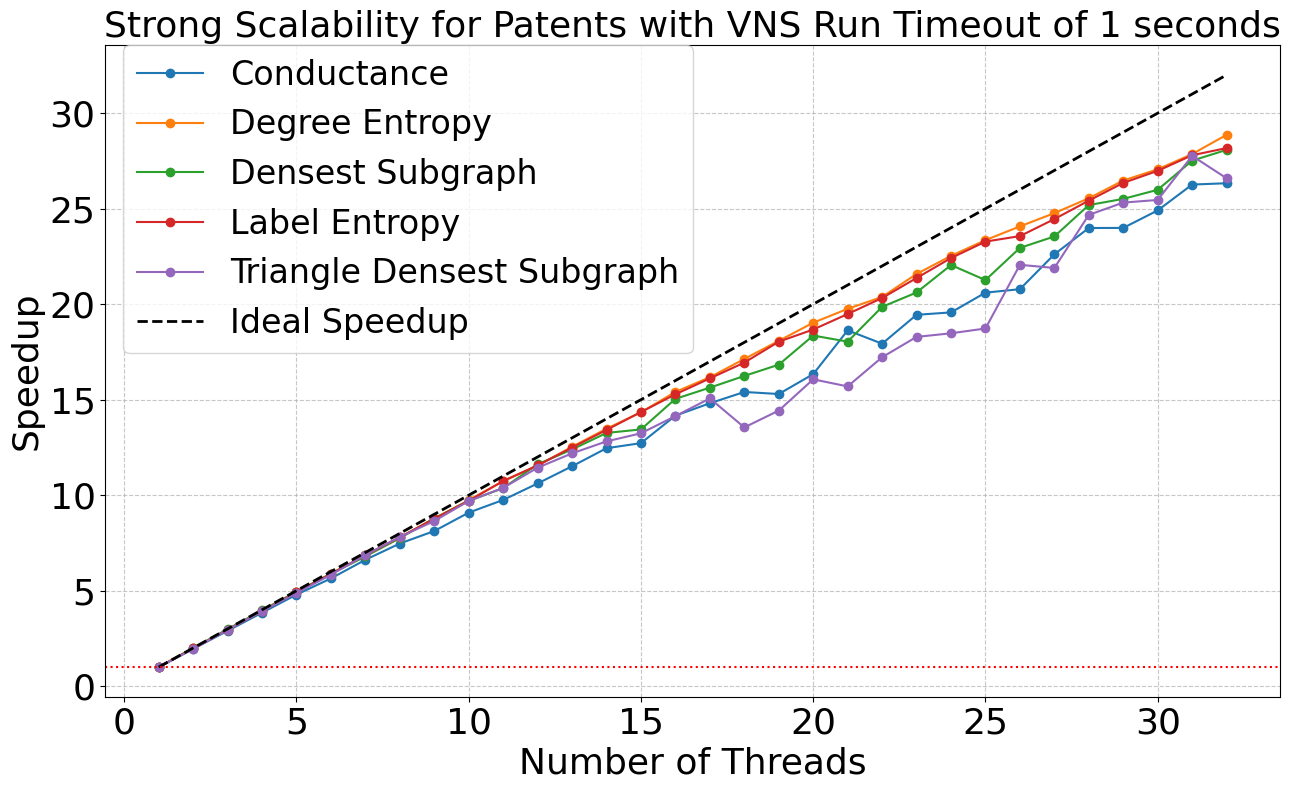

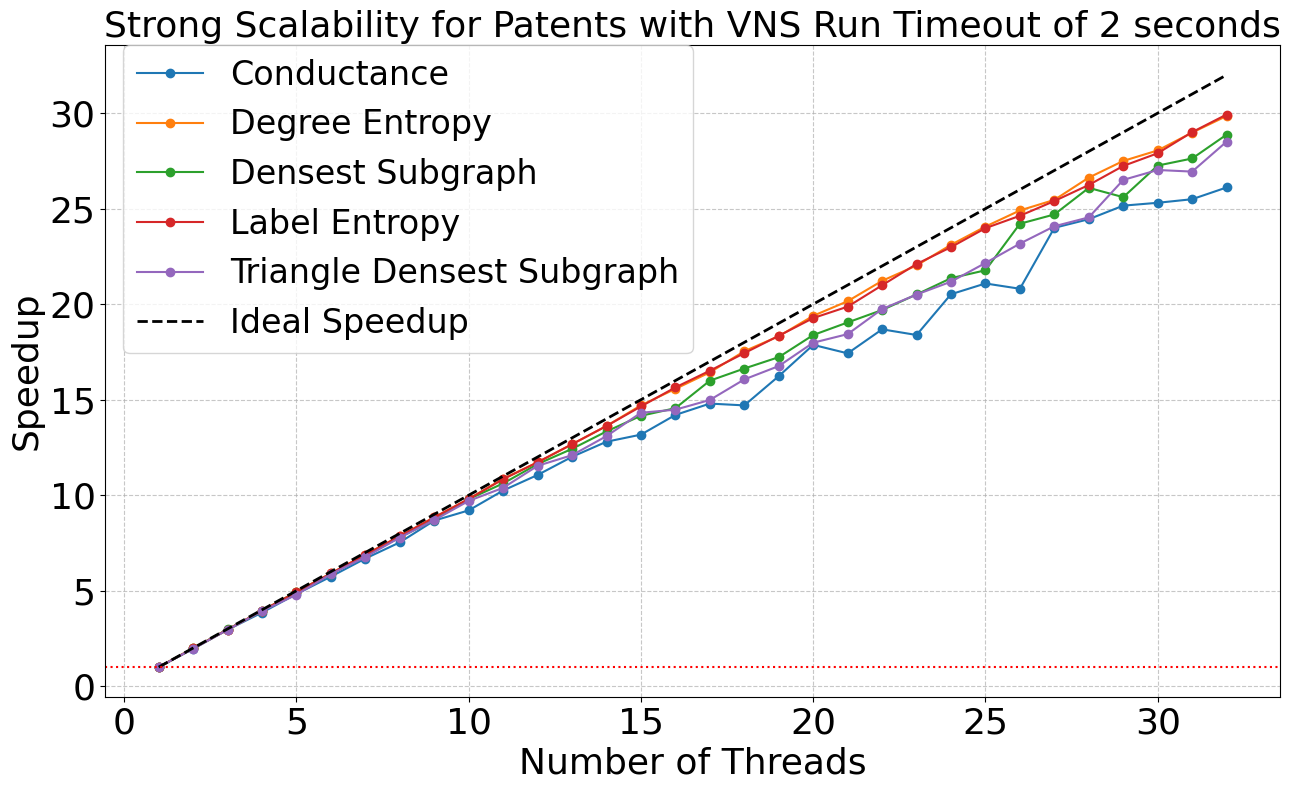

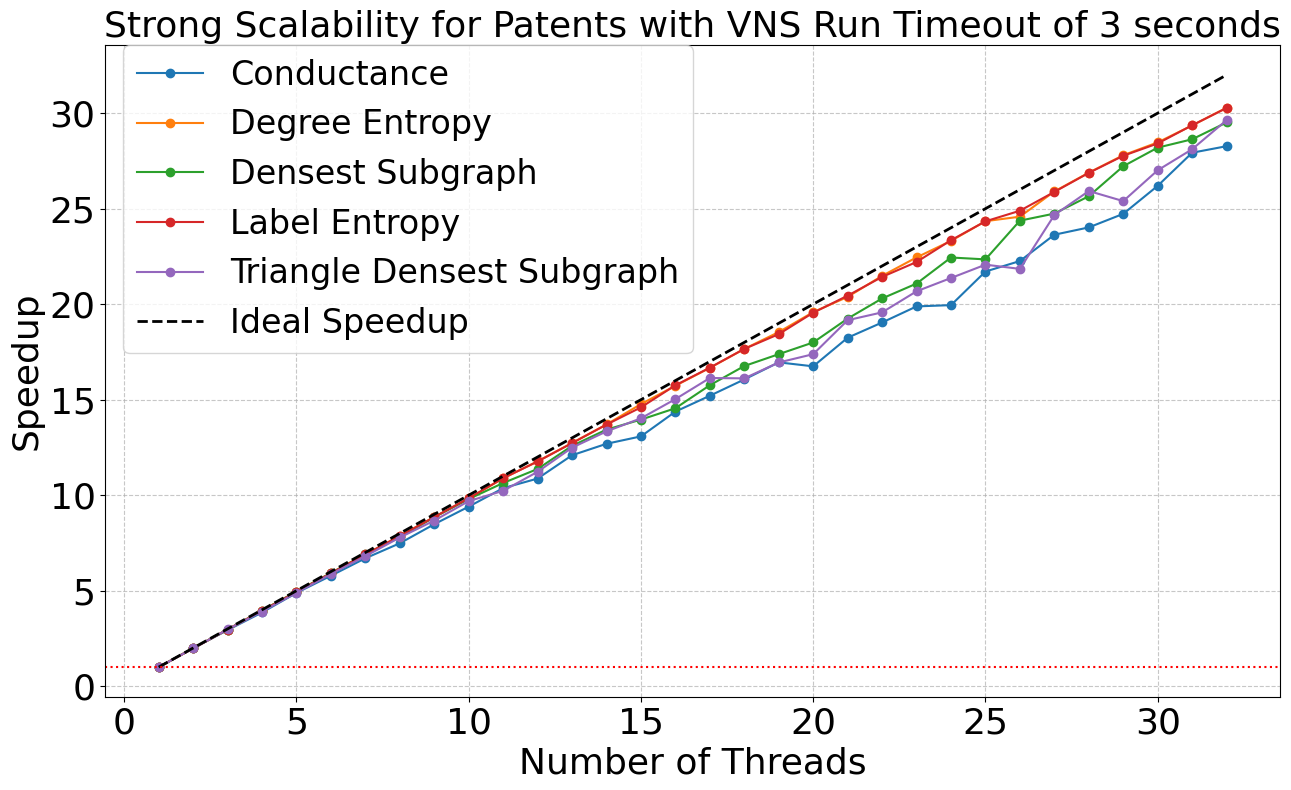

In [7]:
grouping_cols = ["Objective Function"]

df = grouped_df[(grouped_df["Graph Name"] == "patents") & (grouped_df["Initial Solutions"] == 100) & (grouped_df["Timeout (ms)"] == 1000)]
plot_speedup(df, grouping_cols, 'Strong Scalability for Patents with VNS Run Timeout of 1 seconds')

df = grouped_df[(grouped_df["Graph Name"] == "patents") & (grouped_df["Initial Solutions"] == 100) & (grouped_df["Timeout (ms)"] == 2000)]
plot_speedup(df, grouping_cols, 'Strong Scalability for Patents with VNS Run Timeout of 2 seconds')

df = grouped_df[(grouped_df["Graph Name"] == "patents") & (grouped_df["Initial Solutions"] == 100) & (grouped_df["Timeout (ms)"] == 3000)]
plot_speedup(df, grouping_cols, 'Strong Scalability for Patents with VNS Run Timeout of 3 seconds')

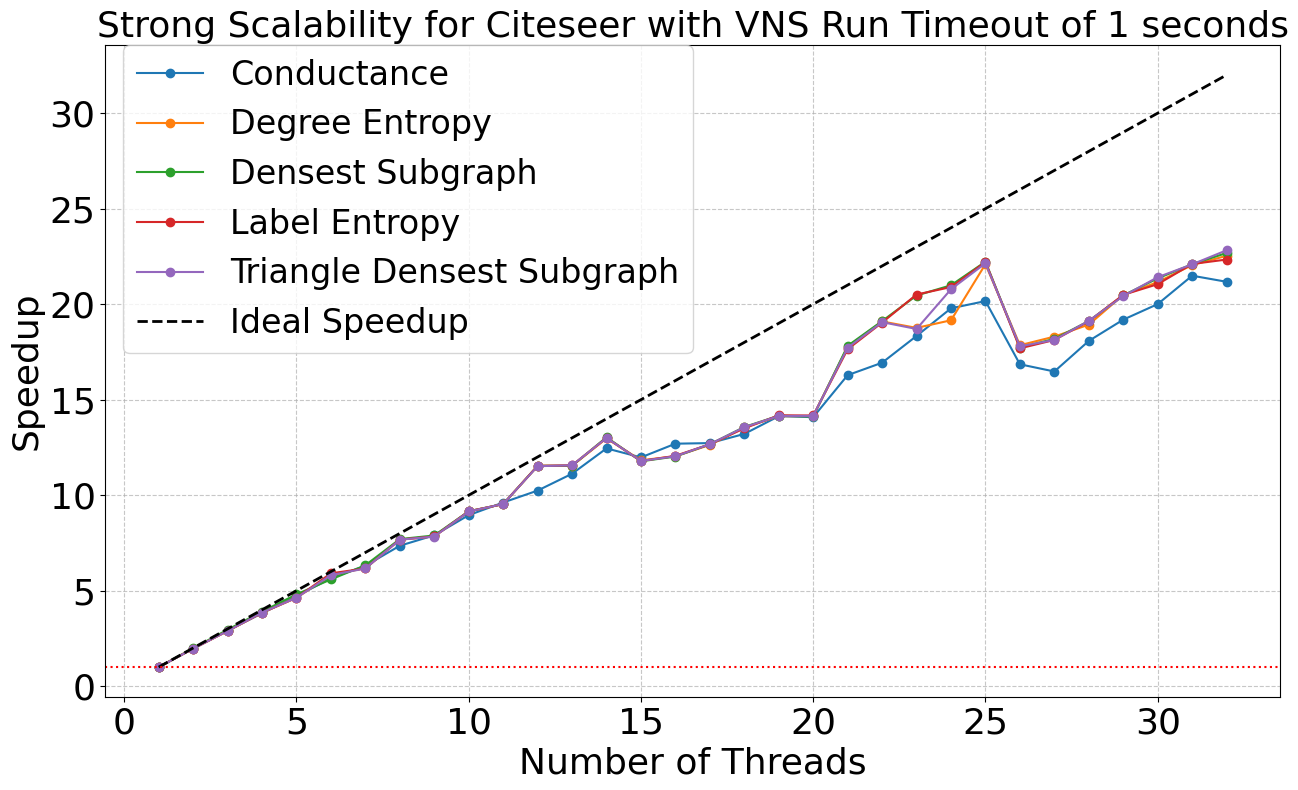

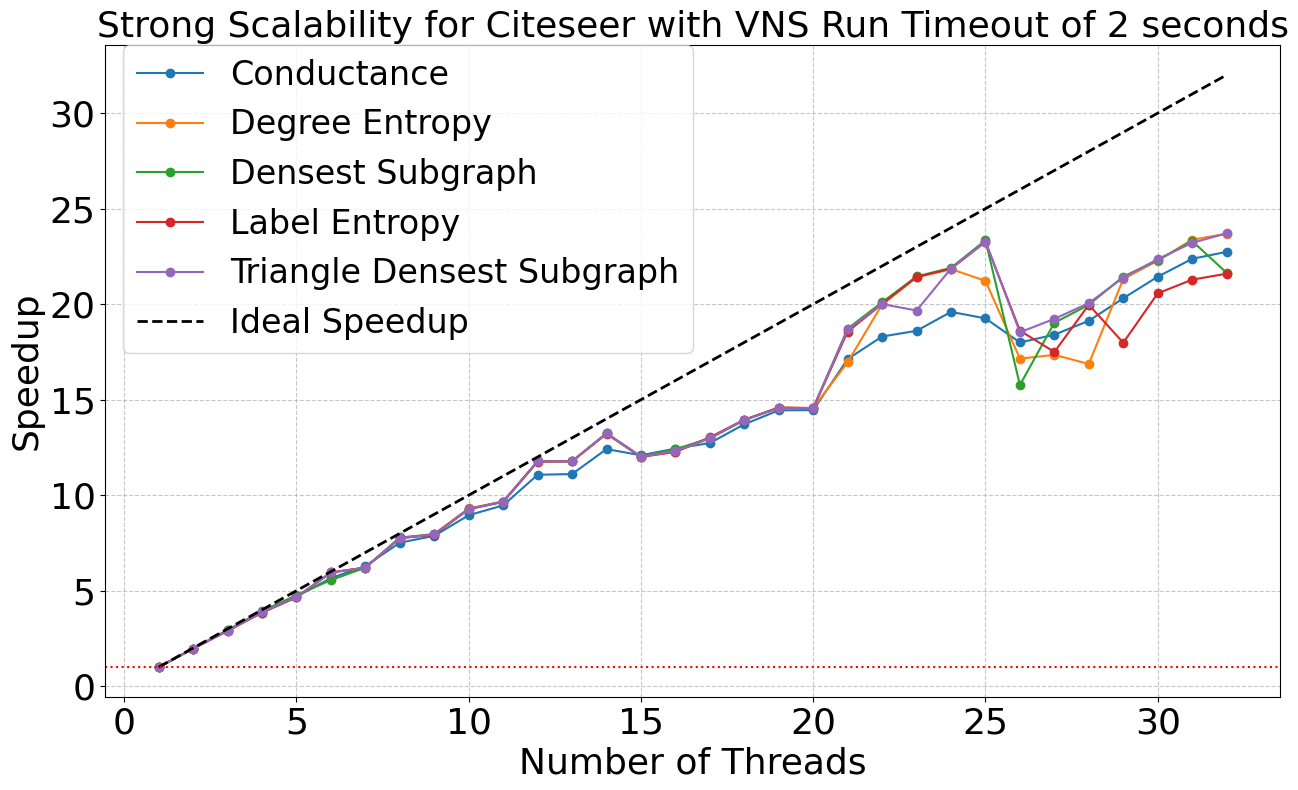

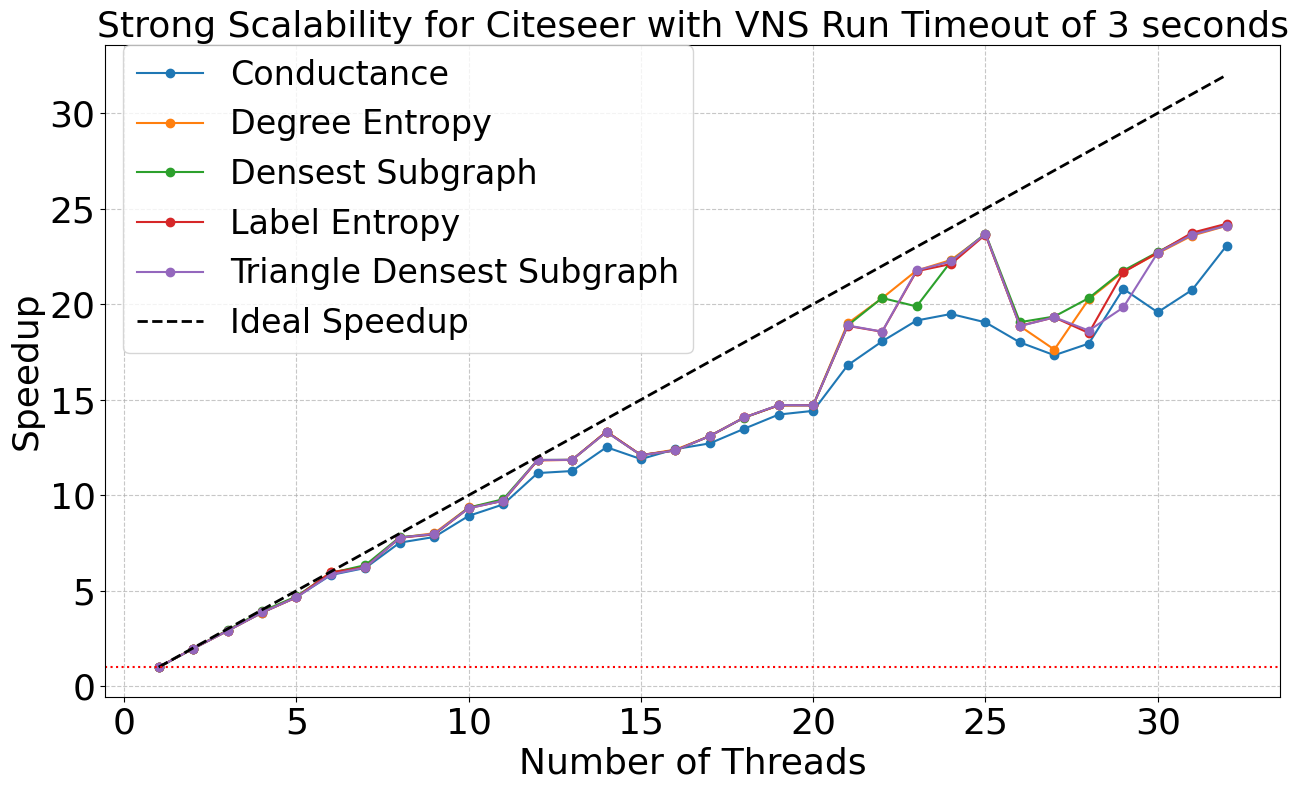

In [8]:
grouping_cols = ["Objective Function"]

df = grouped_df[(grouped_df["Graph Name"] == "citeseer") & (grouped_df["Initial Solutions"] == 100) & (grouped_df["Timeout (ms)"] == 1000)]
plot_speedup(df, grouping_cols, 'Strong Scalability for Citeseer with VNS Run Timeout of 1 seconds')

df = grouped_df[(grouped_df["Graph Name"] == "citeseer") & (grouped_df["Initial Solutions"] == 100) & (grouped_df["Timeout (ms)"] == 2000)]
plot_speedup(df, grouping_cols, 'Strong Scalability for Citeseer with VNS Run Timeout of 2 seconds')

df = grouped_df[(grouped_df["Graph Name"] == "citeseer") & (grouped_df["Initial Solutions"] == 100) & (grouped_df["Timeout (ms)"] == 3000)]
plot_speedup(df, grouping_cols, 'Strong Scalability for Citeseer with VNS Run Timeout of 3 seconds')

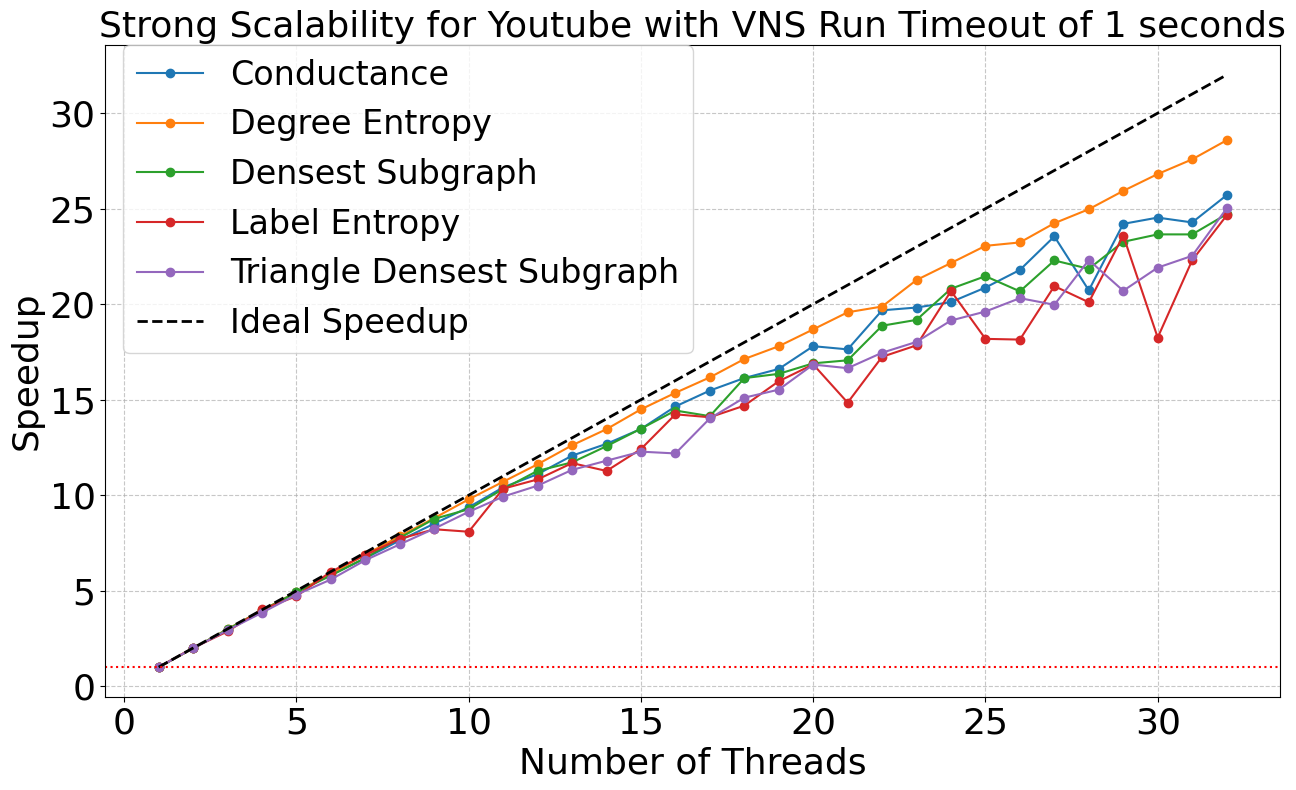

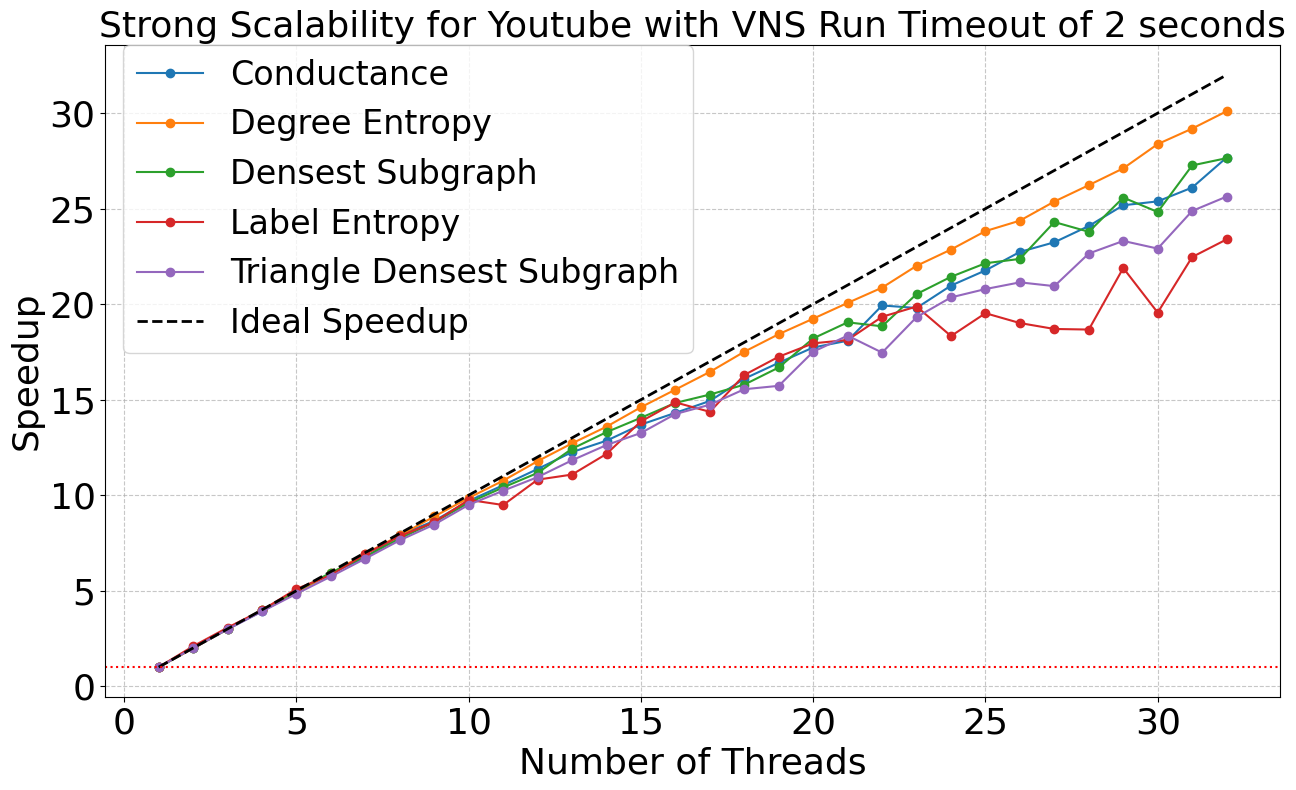

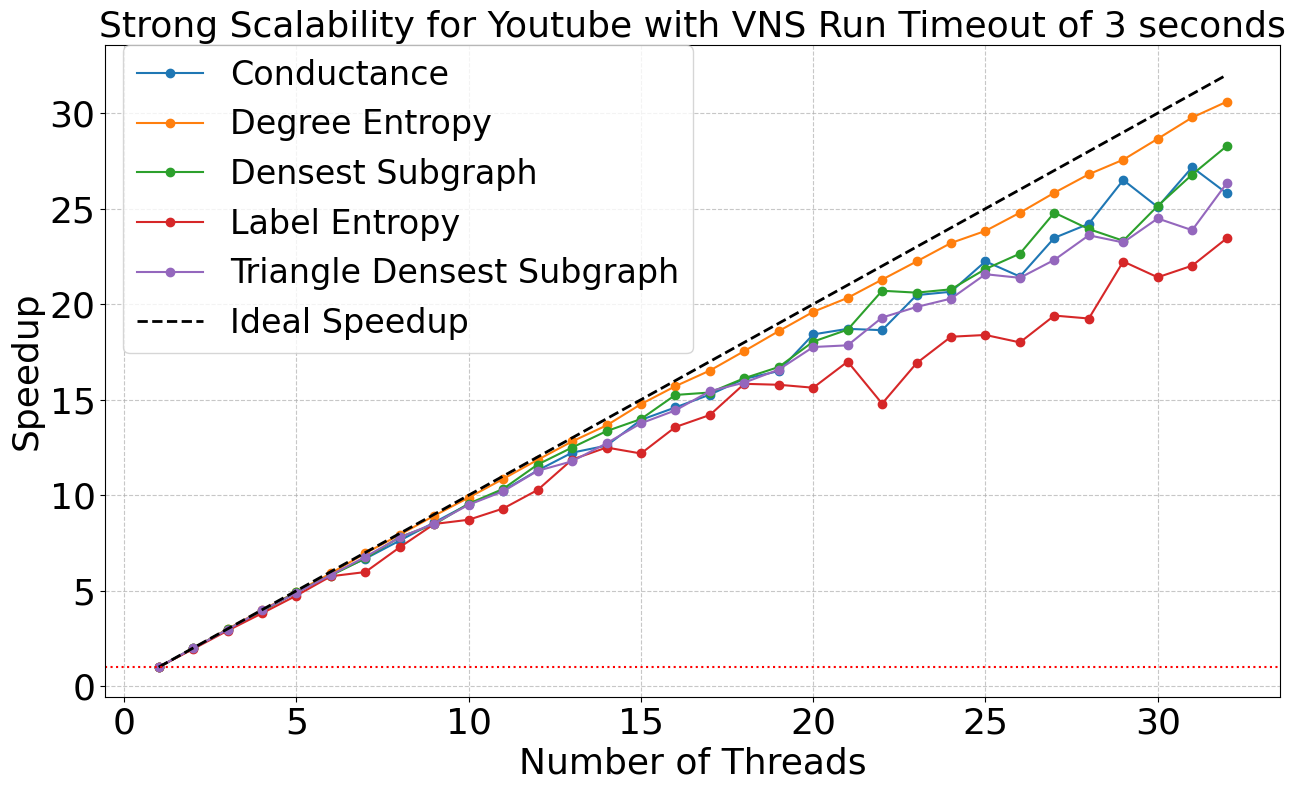

In [9]:
grouping_cols = ["Objective Function"]

df = grouped_df[(grouped_df["Graph Name"] == "youtube") & (grouped_df["Initial Solutions"] == 100) & (grouped_df["Timeout (ms)"] == 1000)]
plot_speedup(df, grouping_cols, 'Strong Scalability for Youtube with VNS Run Timeout of 1 seconds')

df = grouped_df[(grouped_df["Graph Name"] == "youtube") & (grouped_df["Initial Solutions"] == 100) & (grouped_df["Timeout (ms)"] == 2000)]
plot_speedup(df, grouping_cols, 'Strong Scalability for Youtube with VNS Run Timeout of 2 seconds')

df = grouped_df[(grouped_df["Graph Name"] == "youtube") & (grouped_df["Initial Solutions"] == 100) & (grouped_df["Timeout (ms)"] == 3000)]
plot_speedup(df, grouping_cols, 'Strong Scalability for Youtube with VNS Run Timeout of 3 seconds')

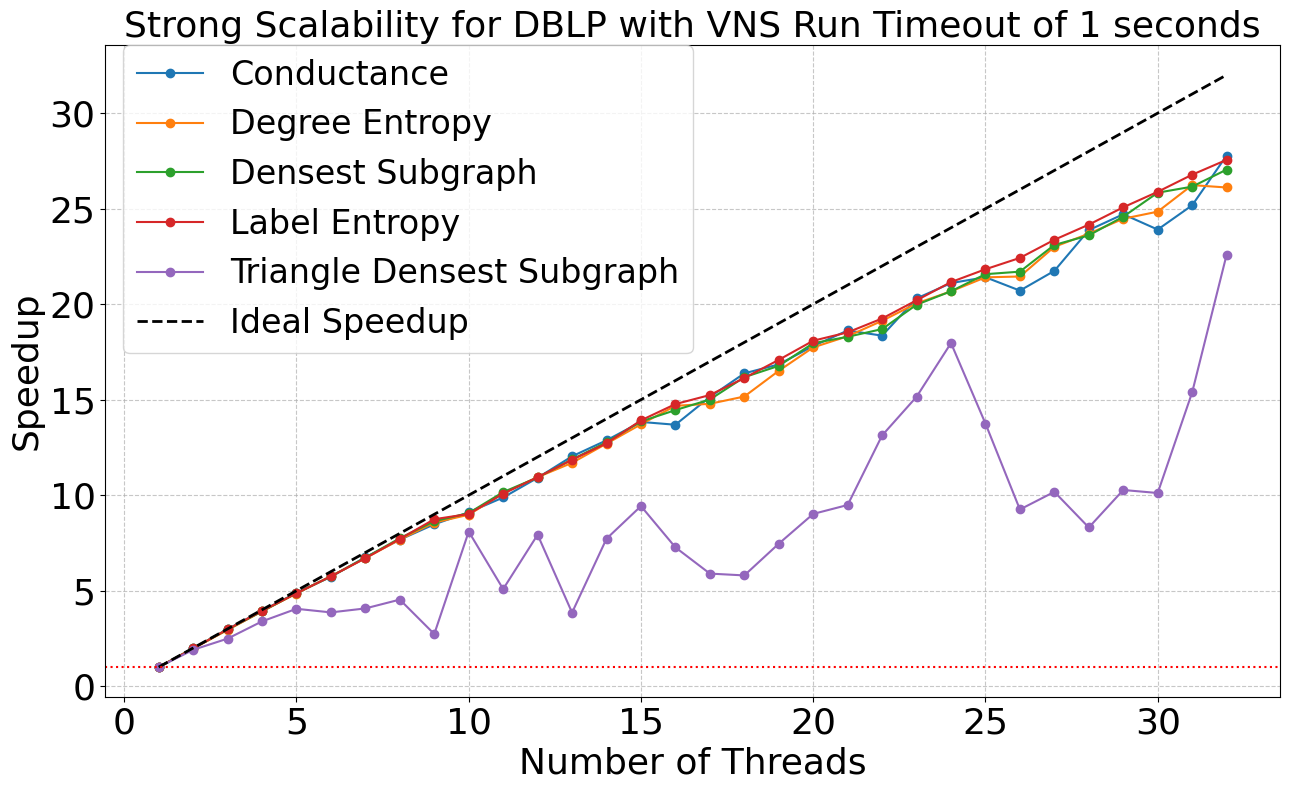

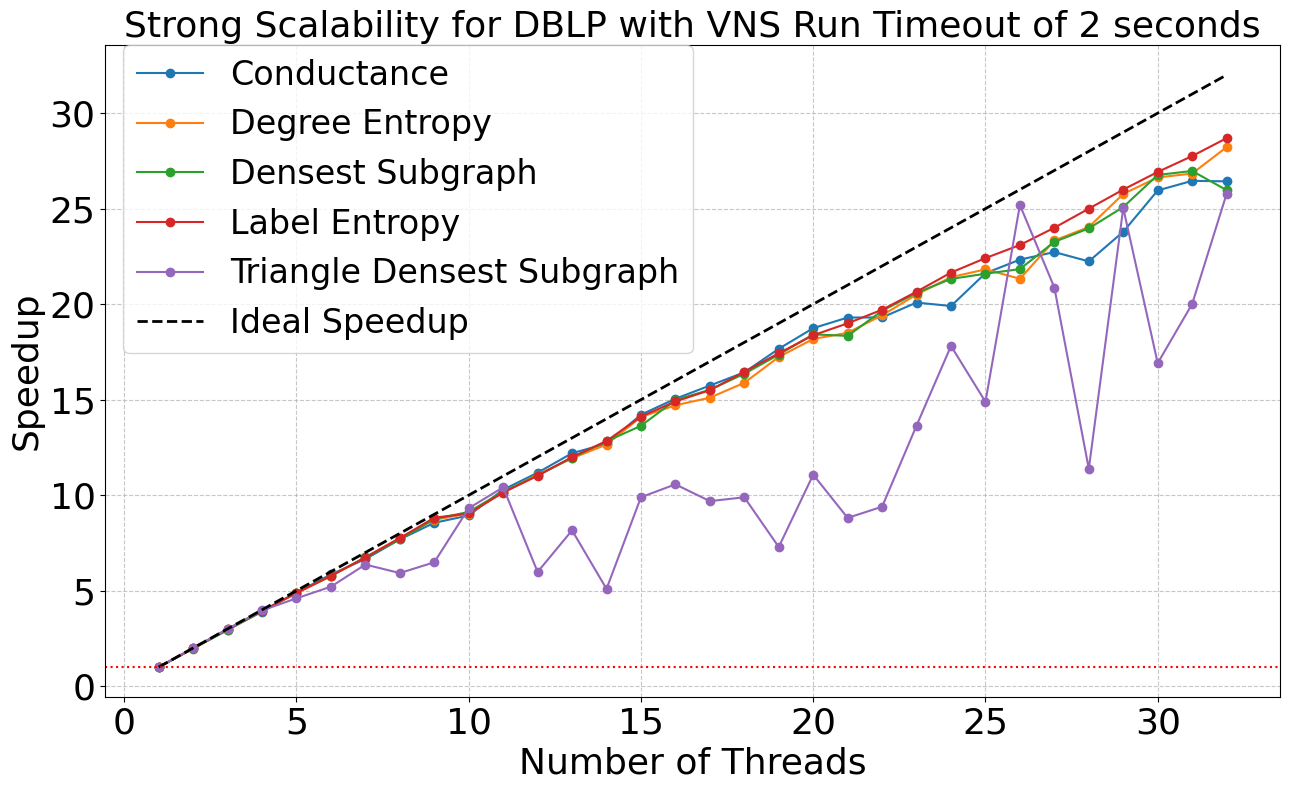

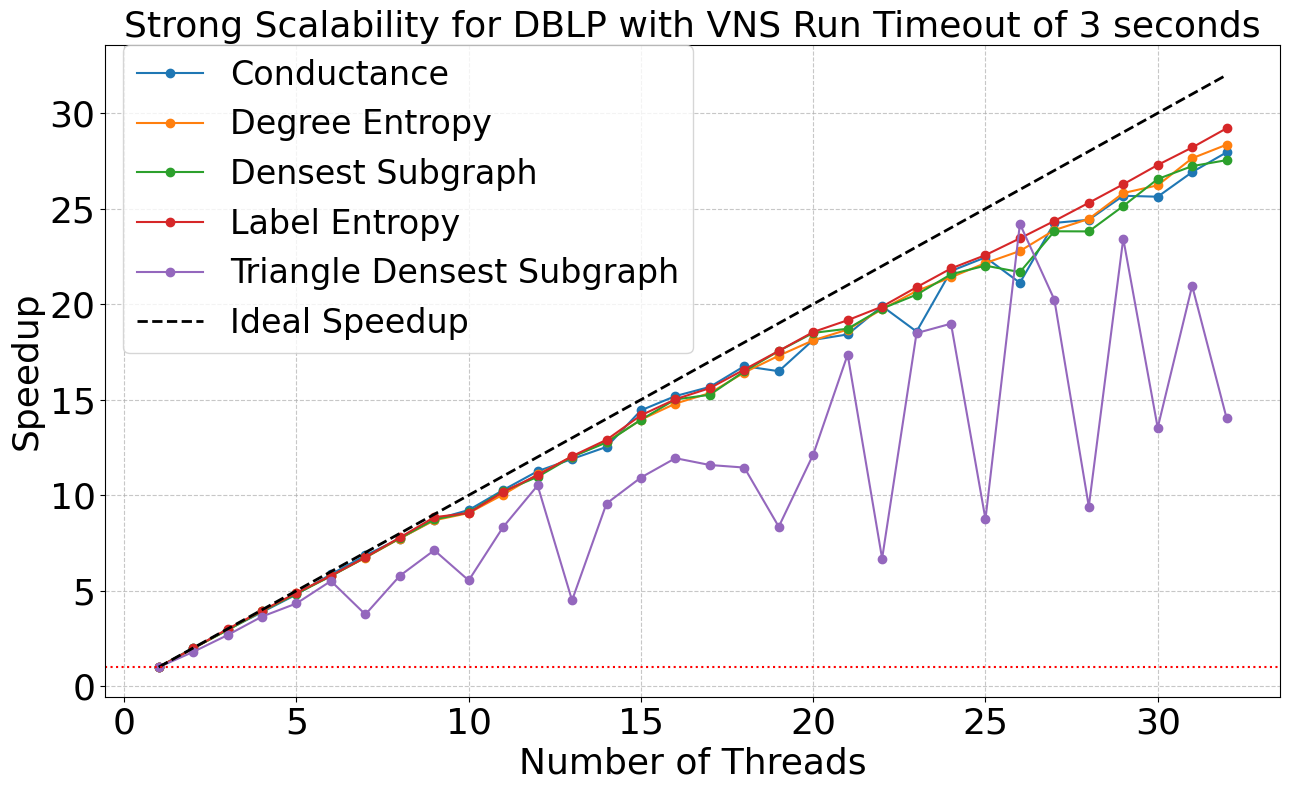

In [10]:
grouping_cols = ["Objective Function"]

df = grouped_df[(grouped_df["Graph Name"] == "dblp") & (grouped_df["Initial Solutions"] == 100) & (grouped_df["Timeout (ms)"] == 1000)]
plot_speedup(df, grouping_cols, 'Strong Scalability for DBLP with VNS Run Timeout of 1 seconds')

df = grouped_df[(grouped_df["Graph Name"] == "dblp") & (grouped_df["Initial Solutions"] == 100) & (grouped_df["Timeout (ms)"] == 2000)]
plot_speedup(df, grouping_cols, 'Strong Scalability for DBLP with VNS Run Timeout of 2 seconds')

df = grouped_df[(grouped_df["Graph Name"] == "dblp") & (grouped_df["Initial Solutions"] == 100) & (grouped_df["Timeout (ms)"] == 3000)]
plot_speedup(df, grouping_cols, 'Strong Scalability for DBLP with VNS Run Timeout of 3 seconds')